In [7]:
import scanpy as sc
import scvi
import seaborn as sns
import pandas as pd
import numpy as np
#!pip install plotly
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
import scvelo as scv

In [8]:
adata = sc.read_h5ad('/python/Results_ann/expr_23days_annotated.h5ad')

In [15]:
gene_list = (
    'CYC1', # 0
    'EIF4A2', # 1
    'RPL13A', # 2
    'RPLP0', # 3
    'ACTB', # 4
    'GAPDH', # 5
    'UBC'# 6
)

In [7]:
gene_list[1]

'EIF4A2'

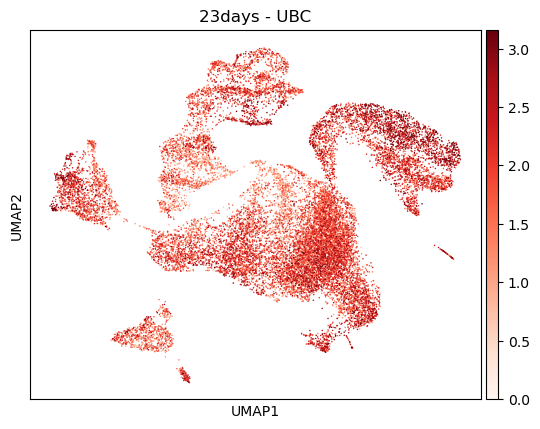

In [14]:
gene=gene_list[7]
sc.pl.umap(adata, 
               color=gene, 
               use_raw=True, 
               color_map='Reds', 
               vmax='p99',
               title=f'23days - {gene}', 
               show=True)

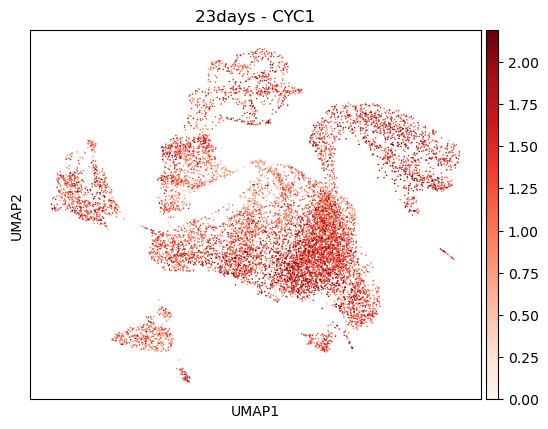

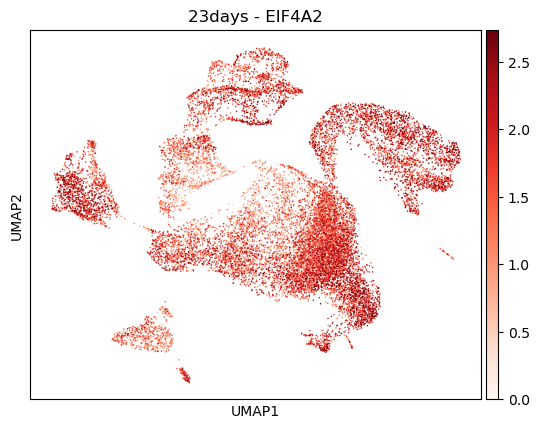

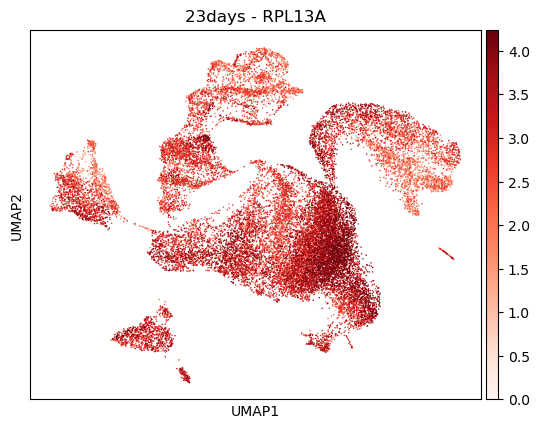

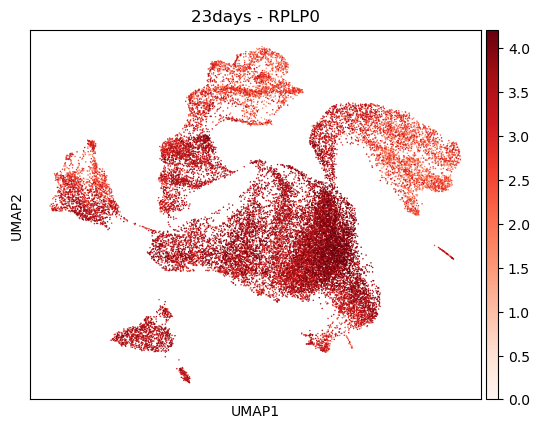

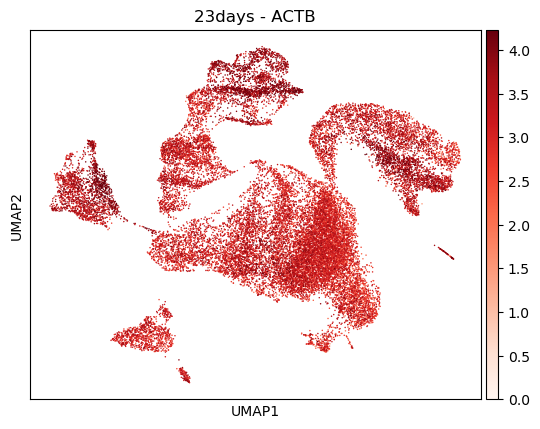

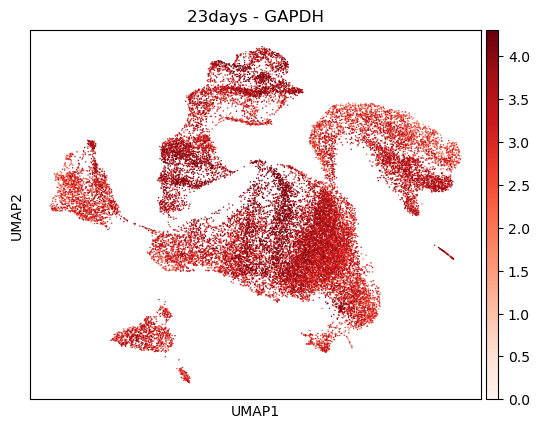

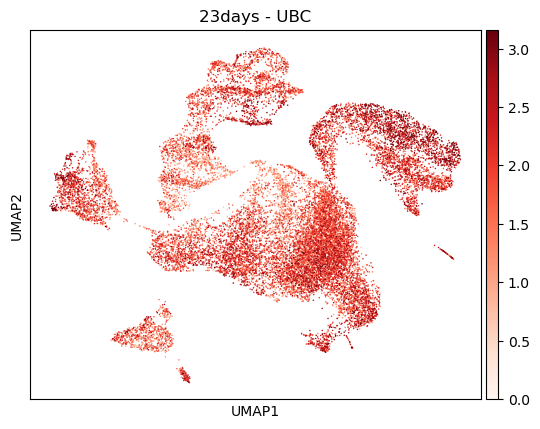

In [16]:
for gene in gene_list:
    sc.pl.umap(adata, 
               color=gene, 
               use_raw=True, 
               color_map='Reds', 
               vmax='p99',
               title=f'23days - {gene}', 
               show=True)

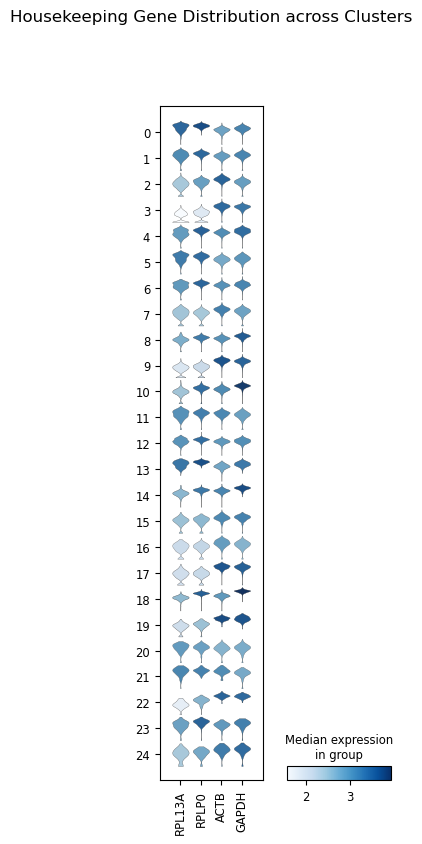

In [9]:
# The list of human neural organoid housekeeping candidates
hk_genes = ['RPL13A', 'RPLP0', 'ACTB', 'GAPDH']
valid_hk = [g for g in hk_genes if g in adata.raw.var_names]

# Plot their distribution across your cell clusters
# Note: replace 'leiden' with the actual column name for your clusters/levels
sc.pl.stacked_violin(
    adata, 
    var_names=valid_hk, 
    groupby='leiden', 
    use_raw=True,
    title="Housekeeping Gene Distribution across Clusters",
    save="_hk_distribution.png"
)

In [10]:
name='2month'
adata = sc.read_h5ad(f'/python/Results_ann/expr_{name}_annotated.h5ad')

--> Calculating background signature score using: ['RPL13A', 'RPLP0', 'ACTB', 'GAPDH']


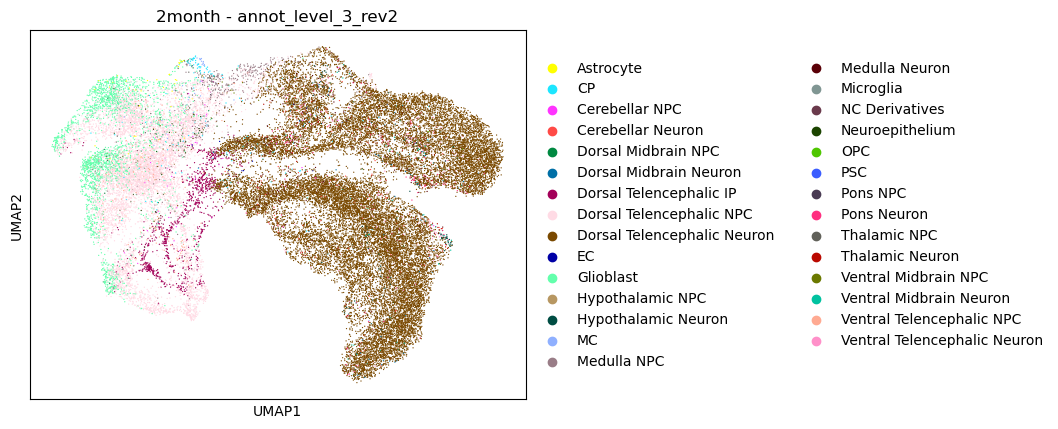

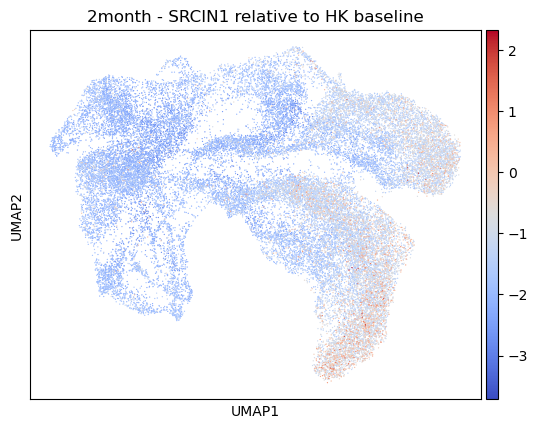

Axes(0.124285,0.15;0.673627x0.73)


In [23]:
hk_genes = ['RPL13A', 'RPLP0', 'ACTB', 'GAPDH']
valid_hk = [g for g in hk_genes if g in adata.raw.var_names]

goi=['SRCIN1']
level='annot_level_3_rev2'
if valid_hk:
        print(f'--> Calculating background signature score using: {valid_hk}')
        sc.tl.score_genes(adata, gene_list=valid_hk, score_name='hk_signature_score', use_raw=True)
        
        # Gene of interest normalized against the housekeeping signature
        for gene in goi:
            if gene in adata.raw.var_names:
                # Extract the raw expression array for the gene of interest
                # (.X might be sparse, so we convert to a dense 1D array)
                import scipy.sparse as sp
                gene_expr = adata.raw[:, gene].X
                if sp.issparse(gene_expr):
                    gene_expr = gene_expr.toarray().flatten()
                else:
                    gene_expr = gene_expr.flatten()
                
                # Using Subtraction because adata.raw is typically log1p transformed
                # log(Gene) - log(HK_baseline) = log(Gene / HK_baseline)
                new_col_name = f'{gene}_relative_to_hk_baseline'
                adata.obs[new_col_name] = gene_expr - adata.obs['hk_signature_score']

                #print(adata.obs)

                sc.pl.umap(adata, 
                           color=level, 
                           title=f'{name} - {level}', 
                           show=True)
                
                sc.pl.umap(adata, 
                           color=new_col_name, 
                           color_map='coolwarm', # coolwarm is great for showing over/under expression (diverging)
                           title=f'{name} - {gene} relative to HK baseline', #save=f'{name}_{gene}_relative_to_hk_umap.png',
                           show=True)

                ax = sc.pl.violin(adata, 
                           keys=new_col_name,
                           groupby=level,
                           rotation=90, 
                           show=False)
                ax.set_title(f'{name} - {gene} relative to HK baseline')
                plt.savefig(f"violin_{name}_{level}_{gene}_relative_to_hk_boxplot.png", bbox_inches="tight")
                plt.close()
                print(ax)

In [24]:
medians = adata.obs.groupby(level, observed=False)[new_col_name].median()
medians

annot_level_3_rev2
Astrocyte                      -1.991552
CP                             -2.026445
Cerebellar NPC                 -2.152007
Cerebellar Neuron              -1.710922
Dorsal Midbrain NPC            -1.974014
Dorsal Midbrain Neuron         -1.395107
Dorsal Telencephalic IP        -2.045715
Dorsal Telencephalic NPC       -2.175718
Dorsal Telencephalic Neuron    -1.449463
EC                             -2.485402
Glioblast                      -2.055359
Hypothalamic NPC               -1.373397
Hypothalamic Neuron            -1.446041
MC                             -2.161442
Medulla NPC                    -1.972786
Medulla Neuron                 -1.862909
Microglia                            NaN
NC Derivatives                 -1.988014
Neuroepithelium                -2.146088
OPC                            -1.435382
PSC                                  NaN
Pons NPC                       -2.255245
Pons Neuron                    -1.559430
Thalamic NPC                   -2.1717

In [25]:
# Create a figure with a specific size (e.g., 12 x 8 inches at 100 DPI)
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)

# 1. Draw the box plot using seaborn (pulling directly from adata.obs)
sns.boxplot(
    data=adata.obs, 
    x=level, 
    y=new_col_name,
    ax=ax,
    color='lightblue', # Customize color as needed
    fliersize=1        # Makes outlier dots smaller (good for single-cell data)
)

# Customize titles and rotate x-axis labels (so clusters are readable)
ax.set_title(f'{name} - {gene} relative to HK baseline')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel('Cluster')
ax.set_ylabel('Relative Expression (log scale)')

# 2. Calculate medians for each group
medians = adata.obs.groupby(level, observed=False)[new_col_name].median()

# 3. Add median values as text on the plot
for i, median in enumerate(medians):
    # 'i' represents the x-coordinate
    ax.text(i, median, f'{median:.2f}', 
            ha='center', va='bottom', weight='bold', color='black')

# 4. Save manually
fig.savefig(f"{sc.settings.figdir}_{name}_{level}_{gene}_relative_to_hk_boxplot.png", bbox_inches='tight')
plt.close(fig)

In [26]:
cells_to_remove = ['EC', 'MC', 'NC Derivatives', 'CP', 'PSC']
clusters_to_remove = ['26', '27', '28', '29', '30']
mask = (~adata.obs[level].isin(cells_to_remove)) & (~adata.obs['leiden'].isin(clusters_to_remove))
adata_tmp = adata[mask].copy()

--> Calculating background signature score using: ['RPL13A', 'RPLP0', 'ACTB', 'GAPDH']


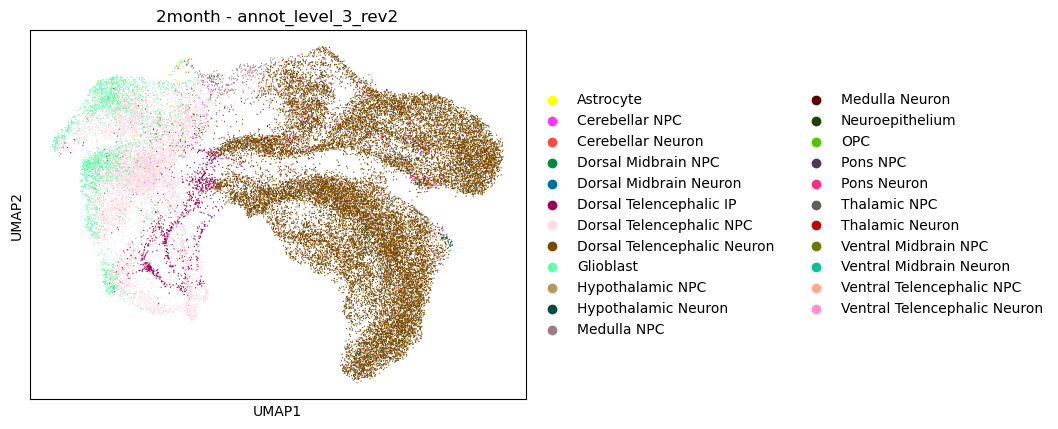

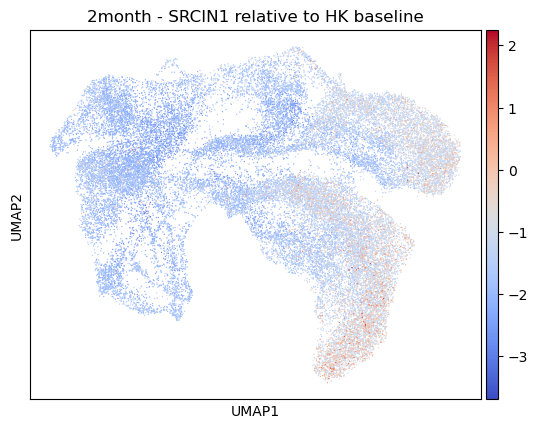

Axes(0.124285,0.15;0.673627x0.73)


In [27]:
hk_genes = ['RPL13A', 'RPLP0', 'ACTB', 'GAPDH']
valid_hk = [g for g in hk_genes if g in adata_tmp.raw.var_names]

goi=['SRCIN1']
level='annot_level_3_rev2'
if valid_hk:
        print(f'--> Calculating background signature score using: {valid_hk}')
        sc.tl.score_genes(adata_tmp, gene_list=valid_hk, score_name='hk_signature_score', use_raw=True)
        
        # Gene of interest normalized against the housekeeping signature
        for gene in goi:
            if gene in adata_tmp.raw.var_names:
                # Extract the raw expression array for the gene of interest
                # (.X might be sparse, so we convert to a dense 1D array)
                import scipy.sparse as sp
                gene_expr = adata_tmp.raw[:, gene].X
                if sp.issparse(gene_expr):
                    gene_expr = gene_expr.toarray().flatten()
                else:
                    gene_expr = gene_expr.flatten()
                
                # Using Subtraction because adata_tmp.raw is typically log1p transformed
                # log(Gene) - log(HK_baseline) = log(Gene / HK_baseline)
                new_col_name = f'{gene}_relative_to_hk_baseline'
                adata_tmp.obs[new_col_name] = gene_expr - adata_tmp.obs['hk_signature_score']

                #print(adata_tmp.obs)

                sc.pl.umap(adata_tmp, 
                           color=level, 
                           title=f'{name} - {level}', 
                           show=True)
                
                sc.pl.umap(adata_tmp, 
                           color=new_col_name, 
                           color_map='coolwarm', # coolwarm is great for showing over/under expression (diverging)
                           title=f'{name} - {gene} relative to HK baseline', #save=f'{name}_{gene}_relative_to_hk_umap.png',
                           show=True)

                ax = sc.pl.violin(adata_tmp, 
                           keys=new_col_name,
                           groupby=level,
                           rotation=90, 
                           show=False)
                ax.set_title(f'{name} - {gene} relative to HK baseline')
                plt.savefig(f"violin_{name}_{level}_filtered_{gene}_relative_to_hk_boxplot.png", bbox_inches="tight")
                plt.close()
                print(ax)

In [28]:
#medians
adata_tmp.obs.groupby(level, observed=False)[new_col_name].median()

annot_level_3_rev2
Astrocyte                      -1.949968
Cerebellar NPC                 -2.147002
Cerebellar Neuron              -1.692436
Dorsal Midbrain NPC            -1.941965
Dorsal Midbrain Neuron         -1.347954
Dorsal Telencephalic IP        -2.021811
Dorsal Telencephalic NPC       -2.152788
Dorsal Telencephalic Neuron    -1.426793
Glioblast                      -2.014373
Hypothalamic NPC               -1.463968
Hypothalamic Neuron            -1.424302
Medulla NPC                    -1.945251
Medulla Neuron                 -1.878283
Neuroepithelium                -2.110536
OPC                            -1.468579
Pons NPC                       -2.271168
Pons Neuron                    -1.502337
Thalamic NPC                   -2.163738
Thalamic Neuron                -1.636578
Ventral Midbrain NPC           -1.944105
Ventral Midbrain Neuron        -1.312595
Ventral Telencephalic NPC      -2.183701
Ventral Telencephalic Neuron   -1.461043
Name: SRCIN1_relative_to_hk_baseline, 

In [29]:
# Create a figure with a specific size (e.g., 12 x 8 inches at 100 DPI)
fig, ax = plt.subplots(figsize=(12, 8), dpi=100)

# 1. Draw the box plot using seaborn (pulling directly from adata_tmp.obs)
sns.boxplot(
    data=adata_tmp.obs, 
    x=level, 
    y=new_col_name,
    ax=ax,
    color='lightblue', # Customize color as needed
    fliersize=1        # Makes outlier dots smaller (good for single-cell data)
)

# Customize titles and rotate x-axis labels (so clusters are readable)
ax.set_title(f'{name} - filtered - {gene} relative to HK baseline')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel('Cluster')
ax.set_ylabel('Relative Expression (log scale)')

# 2. Calculate medians for each group
medians = adata_tmp.obs.groupby(level, observed=False)[new_col_name].median()

# 3. Add median values as text on the plot
for i, median in enumerate(medians):
    # 'i' represents the x-coordinate
    ax.text(i, median, f'{median:.2f}', 
            ha='center', va='bottom', weight='bold', color='black')

# 4. Save manually
fig.savefig(f"{sc.settings.figdir}_{name}_{level}_filtered_{gene}_relative_to_hk_boxplot.png", bbox_inches='tight')
plt.close(fig)